In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene

In [2]:
np.random.seed(1)

#### Independence

Note: independence assumption is a design issue. We cannot varify after.

#### Normality

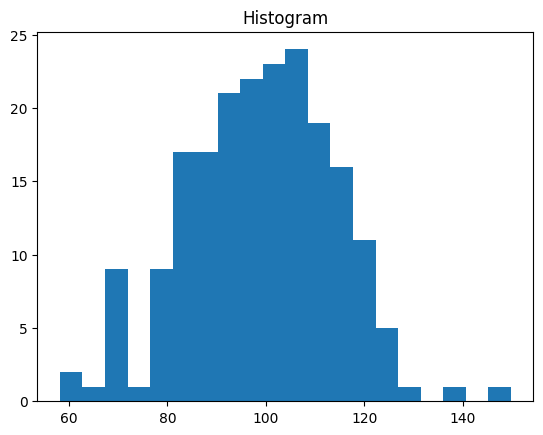

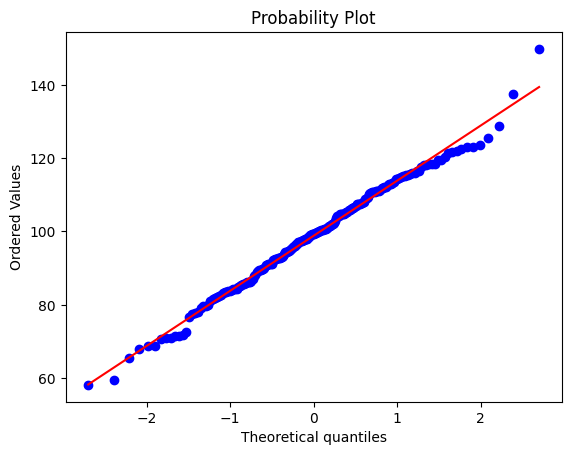

0.9930176345739137
0.46258211868852833


In [9]:
# Using histogram for checking normality.

data = np.random.normal(loc=100, scale=15, size=200)

plt.hist(data, bins=20 )
plt.title("Histogram")

plt.show()

# Using q-q plot for checking normality.

stats.probplot(
    data,
    dist="norm",
    plot=plt
)

plt.show() # Points follow a straight line: normality. Points curve dramatically: potential normality violation.

# Using Shapiro-Wilk Test for checking normality.

statistic, p_value = shapiro(data)

print(statistic)
print(p_value) # p > .05: probably normality. (Note: not valid alone. Always use after histogram and q-q)

#### Homogeneity of Variance

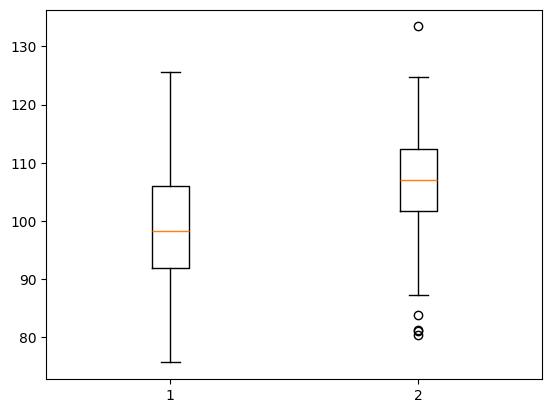

0.08357909582704802
0.7731151599756217
TtestResult(statistic=np.float64(-3.043343316273229), pvalue=np.float64(0.003005364384733673), df=np.float64(97.74556432377857))


In [14]:
# Visual inspection, looking for spread, outliers, variance differences in boxplot.

group1 = np.random.normal(loc=100, scale=10, size=50)
group2 = np.random.normal(loc=105, scale=12, size=50)

plt.boxplot([group1, group2])

plt.show()

# Levene's Test

statistic, p_value = levene(group1, group2)

print(statistic)
print(p_value)

# Ussing Welch's t-test if variance differ.

welch_result =stats.ttest_ind(group1, group2, equal_var=False)

print(welch_result)

#### Assumption-Checking Workflow
1. Histogram
2. Q-Q plots
3. Shapiro-Wilk
4. Levene
5. Decide:
    - If assumptions look reasonable: regular t-test.
    - If variance assumption questionable: Welch's t-test.